In [1]:
"""
Compton scattering gravitonico:  phi(p1) + h(k1,eps1)  ->  phi(p2) + h(k2,eps2)

Diagrammi tree-level con i vertici che abbiamo costruito:
  - canale s: p1+k1 -> phi_interno -> p2+k2   (propagatore scalare)
  - canale u: p1-k2 -> phi_interno -> p2-k1   (propagatore scalare, crossed)
  - canale t: k1-k2 -> h_interno -> emesso verso la linea scalare (p1->p2)
              (propagatore gravitone, vertice a 3 gravitoni + vertice phi-phi-h)

ATTENZIONE - limite fisico di questo calcolo:
  Con H_M^(1) soltanto (lineare in h) NON esiste il termine di contatto
  (seagull) phi-phi-h-h che viene da H_M^(2) (ordine h^2 nell'accoppiamento
  materia-gravita'). Senza quel diagramma l'ampiezza qui sotto NON e'
  gauge-invariante (non soddisfa la Ward identity sotto eps -> eps + k xi + xi k).
  Quello che segue e' quindi solo la parte "scambio scalare + scambio gravitone";
  se ti serve l'ampiezza fisica completa va aggiunto il seagull da H_M^(2).

Convenzioni: eta=diag(1,-1,-1,-1), tutti i momenti nelle formule di vertice
sono INCOMING; per gambe fisicamente uscenti si passa -p (e polarizzazione
reale, niente coniugazione essendo eps reali qui, gauge TT lineare).
"""

import sympy as sp
from sympy import I, Rational, symbols, sqrt, Matrix, nsimplify, simplify
from itertools import permutations

eta = sp.diag(1, -1, -1, -1)


def mink(a, b):
    return sum(a[m] * eta[m, n] * b[n] for m in range(4) for n in range(4))


# --------------------------------------------------------------------------
# vertice phi-phi-h in forma chiusa (derivata in precedenza):
#   iV^{mu nu}(p1,p2) = i/2[ p1^mu p2^nu + p1^nu p2^mu - eta^{mu nu}(p1.p2 - m^2) ]
# p1,p2 = momenti incoming delle due gambe scalari (in quella convenzione).
# --------------------------------------------------------------------------
def VMMH_tensor(p1, p2, m):
    p1p2 = mink(p1, p2)
    V = sp.zeros(4, 4)
    for mu in range(4):
        for nu in range(4):
            V[mu, nu] = Rational(1, 2) * (p1[mu] * p2[nu] + p1[nu] * p2[mu]
                                           - eta[mu, nu] * (p1p2 - m**2))
    return I * V


def VMMH_contract(p1, p2, m, epsmat):
    V = VMMH_tensor(p1, p2, m)
    return sum(V[mu, nu] * epsmat[mu, nu] for mu in range(4) for nu in range(4))


# --------------------------------------------------------------------------
# vertice hhh: riuso esatto della logica gia' testata in hhh_vertex.py, ma
# generalizzato per accettare gambe con dati numerici o con polarizzazione
# simbolica (gamba aperta, per contrarre col propagatore).
# --------------------------------------------------------------------------
I4 = range(4)
I3 = range(1, 4)


def make_eps_symbols(tag):
    d = {}
    for m in I4:
        for n in I4:
            if m <= n:
                d[(m, n)] = symbols(f'eps{tag}_{m}{n}')
    return d


def eps_of(leg, m, n):
    if m > n:
        m, n = n, m
    e = leg['eps']
    if isinstance(e, dict):
        return e[(m, n)]
    return e[m, n]


def hDD(leg, m, n):
    return eps_of(leg, m, n)


def hUU(leg, m, n):
    return sum(eta[m, r] * eta[n, s] * eps_of(leg, r, s) for r in I4 for s in I4)


def hUD(leg, m, n):
    return sum(eta[m, r] * eps_of(leg, r, n) for r in I4)


def trace_h(leg):
    return sum(eta[m, n] * eps_of(leg, m, n) for m in I4 for n in I4)


def Dmu(leg, mu):
    p = leg['p']
    return -I * sum(eta[mu, nu] * p[nu] for nu in I4)


def dd(x, y):
    return Dmu(x, 0) * Dmu(y, 0) + sum(Dmu(x, i) * Dmu(y, i) for i in I3)


def termA(a, b, c):
    s = sum(hUD(a, al, be) * hUD(b, be, al) for al in I4 for be in I4)
    return Rational(1, 2) * dd(b, c) * s * trace_h(c)


def termB(a, b, c):
    tot = 0
    for be in I4:
        for ro in I4:
            for si in I4:
                tot += Dmu(a, be) * hDD(a, ro, si) * (
                    hUU(b, 0, be) * Dmu(c, 0) * hUU(c, ro, si)
                    + sum(hUU(b, ii, be) * Dmu(c, ii) * hUU(c, ro, si) for ii in I3)
                )
    return -Rational(1, 2) * tot


def termC(a, b, c):
    s = sum(hUU(a, al, be) * hUD(b, si, al) * hDD(c, be, si)
            for al in I4 for be in I4 for si in I4)
    return -dd(b, c) * s


def termD(a, b, c):
    s = sum(hDD(b, m, n) * hUU(c, m, n) for m in I4 for n in I4)
    return Rational(1, 4) * trace_h(a) * dd(b, c) * s


def termE(a, b, c):
    return sum(hUD(a, be, 0) * Dmu(b, 0) * hUD(b, si, 0) * Dmu(c, 0) * hDD(c, si, be)
               for be in I4 for si in I4)


def termF(a, b, c):
    tot = 0
    for be in I4:
        for si in I4:
            for j in I3:
                for ii in I3:
                    tot += hUD(a, be, j) * Dmu(b, j) * hUD(b, si, ii) * Dmu(c, ii) * hDD(c, be, si)
    return -tot


def hhh_kernel(leg1, leg2, leg3):
    tot = 0
    for perm in permutations([leg1, leg2, leg3]):
        a, b, c = perm
        tot += termA(a, b, c) + termB(a, b, c) + termC(a, b, c) \
            + termD(a, b, c) + termE(a, b, c) + termF(a, b, c)
    return sp.expand(tot)


def iVHHH_open(legA, legB, legC_p, tag='q'):
    """Vertice a 3 gravitoni con gambe A,B numeriche (p ed eps fissati) e la
    gamba C con momento numerico legC_p ma polarizzazione simbolica.
    Ritorna il tensore aperto T[mu][nu] (sympy Matrix 4x4) tale che
    iV = sum_{mu,nu} T[mu,nu] * eps_C[mu,nu]."""
    epsC = make_eps_symbols(tag)
    legC = {'p': legC_p, 'eps': epsC}
    kernel = hhh_kernel(legA, legB, legC)
    iV = sp.expand(I * (-1) * kernel)

    T = sp.zeros(4, 4)
    for m in I4:
        for n in I4:
            if m > n:
                continue
            sym = epsC[(m, n)]
            coeff = iV.coeff(sym)
            if m == n:
                T[m, n] = coeff
            else:
                T[m, n] = coeff / 2
                T[n, m] = coeff / 2
    # controllo: l'espressione deve essere interamente lineare nei 10 simboli
    resid = iV
    for (m, n), sym in epsC.items():
        resid = resid.subs(sym, 0)
    assert sp.simplify(resid) == 0, "residuo non nullo: la sostituzione simbolica non ha coperto tutti i termini"
    return T


# --------------------------------------------------------------------------
# propagatori
# --------------------------------------------------------------------------
def scalar_prop(q, m):
    q2 = mink(q, q)
    return I / (q2 - m**2)


def graviton_prop_contract(Topen1, q, Topen2):
    """i/q^2 * 1/2(eta_mr eta_ns + eta_ms eta_nr - eta_mn eta_rs), contratto
    tra due tensori aperti simmetrici T1[mu,nu], T2[rho,sigma]."""
    q2 = mink(q, q)
    tot = 0
    for mu in I4:
        for nu in I4:
            for ro in I4:
                for si in I4:
                    P = Rational(1, 2) * (eta[mu, ro] * eta[nu, si] + eta[mu, si] * eta[nu, ro]
                                           - eta[mu, nu] * eta[ro, si])
                    tot += Topen1[mu, nu] * P * Topen2[ro, si]
    return I / q2 * tot


# --------------------------------------------------------------------------
# cinematica: CM frame, m=1, |p|=|k|=p_cm fissato, angolo di scattering theta
# --------------------------------------------------------------------------
m_val = 1
p_cm = 1
theta = sp.pi / 3  # 60 gradi, esempio

E1 = sp.sqrt(p_cm**2 + m_val**2)

p1 = [E1, 0, 0, -p_cm]              # scalare incoming
k1 = [p_cm, 0, 0, p_cm]             # gravitone incoming, lungo +z
p2 = [E1, -p_cm * sp.sin(theta), 0, -p_cm * sp.cos(theta)]   # scalare outgoing
k2 = [p_cm, p_cm * sp.sin(theta), 0, p_cm * sp.cos(theta)]   # gravitone outgoing

# check conservazione
cons = [sp.simplify(p1[i] + k1[i] - p2[i] - k2[i]) for i in range(4)]
assert all(c == 0 for c in cons), cons

# basi di polarizzazione TT per k1 (lungo z) e k2 (nel piano x-z, angolo theta)
def tt_pol(e1, e2, kind):
    # eps_ij = (e1 e1 - e2 e2)/sqrt2   [kind='+']   oppure (e1 e2+e2 e1)/sqrt2 [kind='x']
    M = sp.zeros(4, 4)
    for i in range(1, 4):
        for j in range(1, 4):
            if kind == '+':
                M[i, j] = (e1[i] * e1[j] - e2[i] * e2[j]) / sqrt(2)
            else:
                M[i, j] = (e1[i] * e2[j] + e2[i] * e1[j]) / sqrt(2)
    return M


e1_k1 = [0, 1, 0, 0]
e2_k1 = [0, 0, 1, 0]
eps1 = tt_pol(e1_k1, e2_k1, '+')

e1_k2 = [0, sp.cos(theta), 0, -sp.sin(theta)]
e2_k2 = [0, 0, 1, 0]
eps2 = tt_pol(e1_k2, e2_k2, '+')

# controllo gauge TT: niente componenti temporali, trasversalita', traccia nulla
for eps, k in [(eps1, k1), (eps2, k2)]:
    assert all(eps[0, j] == 0 for j in range(4))
    trns = [sp.simplify(sum(k[i] * eps[i, j] for i in range(1, 4))) for j in range(4)]
    assert all(t == 0 for t in trns), trns
    tr = sp.simplify(sum(eta[i, i] * eps[i, i] for i in range(1, 4)))
    assert tr == 0

# --------------------------------------------------------------------------
# diagrammi
# --------------------------------------------------------------------------
def neg(v):
    return [-x for x in v]


# canale s: p1+k1 -> phi -> p2+k2
q_s = [p1[i] + k1[i] for i in range(4)]
Vs1 = VMMH_contract(p1, neg(q_s), m_val, eps1)
Vs2 = VMMH_contract(q_s, neg(p2), m_val, eps2)
Ds = scalar_prop(q_s, m_val)
M_s = Vs1 * Ds * Vs2

# canale u: p1-k2 -> phi -> p2-k1
q_u = [p1[i] - k2[i] for i in range(4)]
Vu1 = VMMH_contract(p1, neg(q_u), m_val, eps2)
Vu2 = VMMH_contract(q_u, neg(p2), m_val, eps1)
Du = scalar_prop(q_u, m_val)
M_u = Vu1 * Du * Vu2

# canale t: k1-k2 -> h -> linea scalare p1->p2
q_t = [k1[i] - k2[i] for i in range(4)]
legA = {'p': k1, 'eps': eps1}
legB = {'p': neg(k2), 'eps': eps2}
T_hhh = iVHHH_open(legA, legB, neg(q_t))          # tensore aperto lato gravitonico
T_mmh = VMMH_tensor(p1, neg(p2), m_val)           # tensore aperto lato materia (senza fattore i extra: gia' incluso)
M_t = graviton_prop_contract(T_hhh, q_t, T_mmh)

M_total = sp.simplify(M_s + M_u + M_t)

print("theta =", theta, "  p_cm =", p_cm, "  m =", m_val)
print()
print("M_s (scambio scalare, canale s) =", sp.nsimplify(sp.simplify(M_s)))
print("M_u (scambio scalare, canale u) =", sp.nsimplify(sp.simplify(M_u)))
print("M_t (scambio gravitone, canale t) =", sp.nsimplify(sp.simplify(M_t)))
print()
print("M totale (SENZA seagull, non gauge invariante) =", M_total)

theta = pi/3   p_cm = 1   m = 1

M_s (scambio scalare, canale s) = 0
M_u (scambio scalare, canale u) = -9*I/224 + 9*sqrt(2)*I/112
M_t (scambio gravitone, canale t) = I*(-30*sqrt(2) - 17)/32

M totale (SENZA seagull, non gauge invariante) = -6*sqrt(2)*I/7 - 4*I/7


Computing noise kernel...


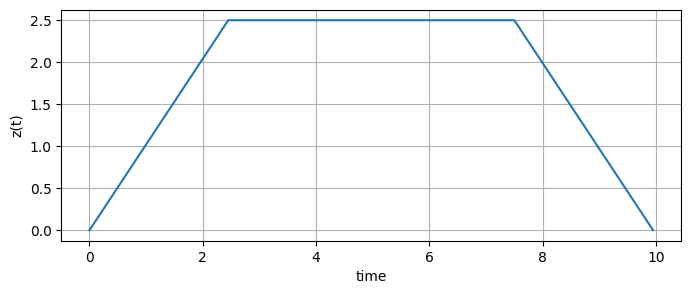

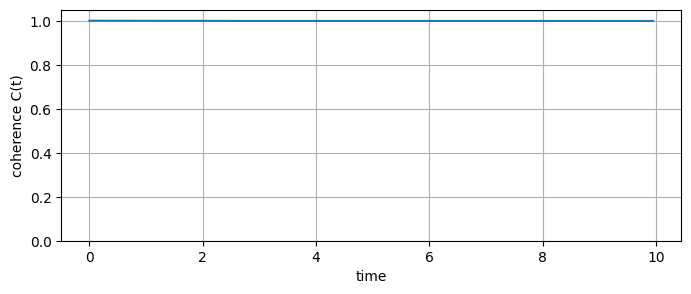

Minimum eigenvalue of N:
-0.42907928265282136
